### **Cell Identitas**

In [ ]:
NAMA = 'Muhammad Pearl Ocshada'
NIM  = '244107020064'          # ganti dengan NIM sendiri
print(NAMA, NIM)

Muhammad Pearl Ocshada 244107020064


In [ ]:
import cv2 as cv
import numpy as np
from matplotlib import pyplot as plt
import math
from google.colab.patches import cv2_imshow
from PIL import Image as im

### **Akses File**

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import cv2 as cv
import math
from google.colab.patches import cv2_imshow
from PIL import Image as im

### **Fungsi Konvolusi**

parameter yang digunakan boleh dimodifikasi.
Misal, hanya menggunakan parameter image dan kernel saja, atau image, kernel, dan
padding.

In [ ]:
def convolution2d(image, kernel, stride, padding):

    image = np.pad(
        image,
        pad_width=padding,
        mode='constant',
        constant_values=0
    )

    kernel_height, kernel_width = kernel.shape
    image_height, image_width = image.shape

    output_height = int((image_height - kernel_height) / stride) + 1
    output_width = int((image_width - kernel_width) / stride) + 1

    output = np.zeros((output_height, output_width))

    for y in range(0, output_height):
        for x in range(0, output_width):

            region = image[
                y * stride:y * stride + kernel_height,
                x * stride:x * stride + kernel_width
            ]

            output[y, x] = np.sum(region * kernel)
    return output


## **Average filter, low pass filter, high pass filter, dan lainnya**


In [ ]:
kernel_sharpen = np.array(
    [
  [0,-1,0],
  [-1,5,-1],
  [0,-1,0]
    ]
  )
kernel_emboss = np.array (
    [
        [-2,-1,0],
         [-1,1,1],
          [0,1,2]
    ]
  )
kernel_sobel = np.array(
    [
        [1,0,-1],
        [2,0,-2],
        [1,0,-1]
    ]
)
kernel_canny = np.array(
    [
        [-1,-1,-1],
        [-1,8,-1],
        [-1,-1,-1]
    ]
)
kernel_size = 21
sigma=math.sqrt(kernel_size)
kernel_gaussian = cv.getGaussianKernel(kernel_size, sigma)
gaussian_kernel = kernel_gaussian @ kernel_gaussian.transpose()


### **Visualisasi Hasil Kernel**

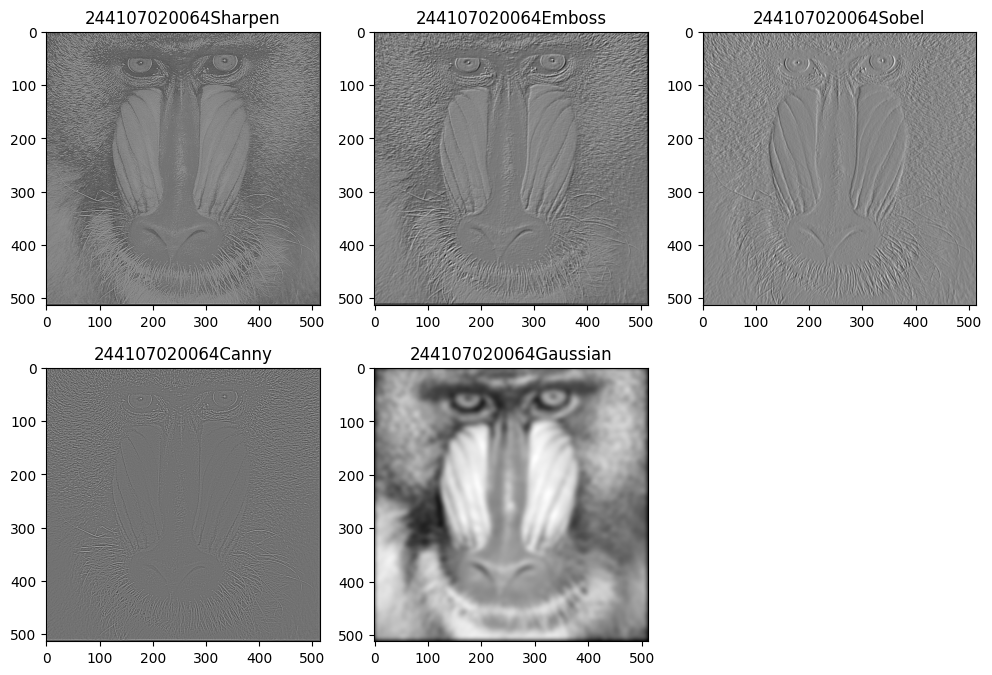

In [ ]:
# Re-run convolution using the updated function
hasil_sharpen = convolution2d(img_gray, kernel_sharpen, 1, 2)
hasil_emboss = convolution2d(img_gray, kernel_emboss, 1, 2)
hasil_sobel = convolution2d(img_gray, kernel_sobel, 1, 2)
hasil_canny = convolution2d(img_gray, kernel_canny, 1, 2)
hasil_gaussian = convolution2d(img_gray, gaussian_kernel, 1, 10)

#Visualisasi Hasil
plt.figure(figsize=(12,8))

plt.subplot(2,3,1)
plt.imshow(hasil_sharpen, cmap='gray')
plt.title(NIM+ 'Sharpen')

plt.subplot(2,3,2)
plt.imshow(hasil_emboss, cmap='gray')
plt.title(NIM+ 'Emboss')

plt.subplot(2,3,3)
plt.imshow(hasil_sobel, cmap='gray')
plt.title(NIM+ 'Sobel')

plt.subplot(2,3,4)
plt.imshow(hasil_canny, cmap='gray')
plt.title(NIM+ 'Canny')

plt.subplot(2,3,5)
plt.imshow(hasil_gaussian, cmap='gray')
plt.title(NIM+ 'Gaussian')

plt.show()

# **Filter Library dan Filter Modern**
## **Percobaan 1**
**Filter Gaussian, Sharpen, dan Canny menggunakan library
filter2d dari OpenCV**

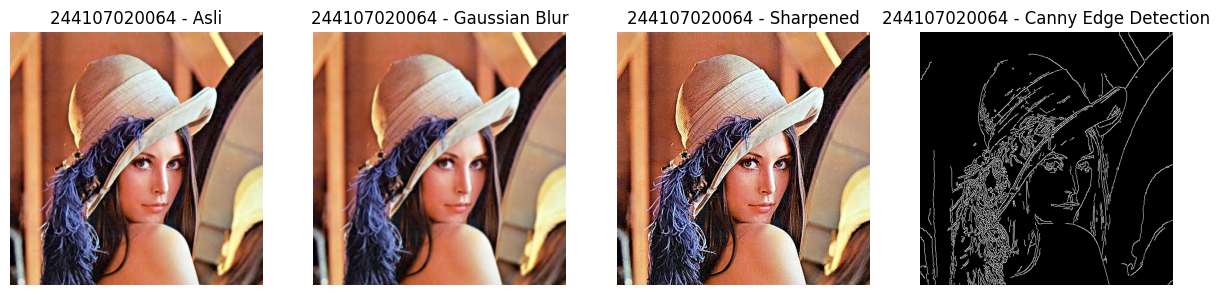

In [ ]:
# Fungsi tampil berdampingan
def show_side_by_side(images, titles, figsize=(15,5)):
    plt.figure(figsize=figsize)
    for i, (img, title) in enumerate(zip(images, titles)):
        if len(img.shape) == 2:  # grayscale
            plt.subplot(1, len(images), i+1)
            plt.imshow(img, cmap='gray')
        else:  # color
            plt.subplot(1, len(images), i+1)
            plt.imshow(cv.cvtColor(img, cv.COLOR_BGR2RGB))
        plt.title(title)
        plt.axis("off")
    plt.show()


img = cv.imread('/content/drive/MyDrive/PCVK/Images/lena.jpg')
img_gray = cv.cvtColor(img, cv.COLOR_BGR2GRAY)

blur = cv.GaussianBlur(img, (7,7), 1)
edges = cv.Canny(img_gray, 100, 200)

sharpen_kernel = np.array([[0,-1,0],[-1,5,-1],[0,-1,0]])
sharpened = cv.filter2D(img, -1, sharpen_kernel)

show_side_by_side([img, blur, sharpened, edges],
                  [NIM+" - Asli",
                   NIM+" - Gaussian Blur",
                   NIM+" - Sharpened",
                   NIM+" - Canny Edge Detection"])

## **Percobaan 2**
**FIltering modern dari openCV**

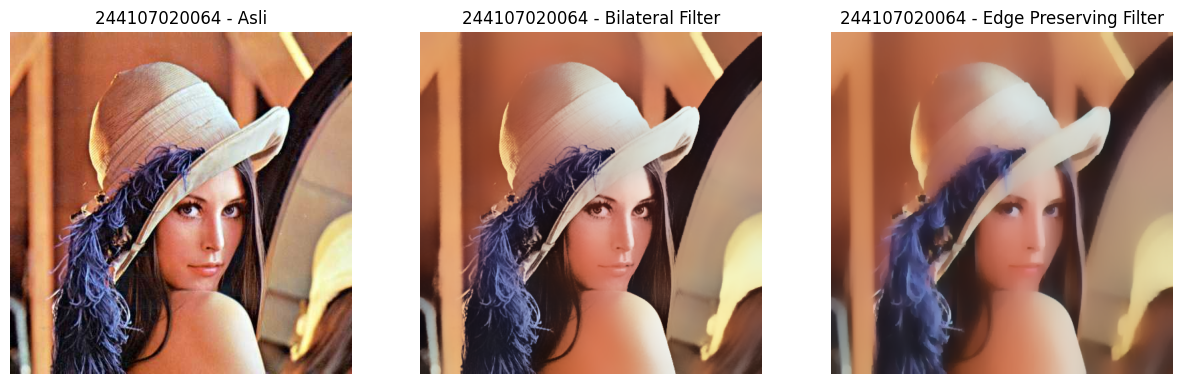

In [ ]:
#Filter Modern dari OpenCV
# Bilateral Filter (edge-preserving)
bilateral = cv.bilateralFilter(img, 50, 100, 100)

# Edge Preserving Filter (alternatif Guided Filter)
edge_preserve = cv.edgePreservingFilter(img, flags=1, sigma_s=100, sigma_r=0.9)

show_side_by_side([img, bilateral, edge_preserve],
                  [NIM+" - Asli",
                   NIM+" - Bilateral Filter",
                   NIM+" - Edge Preserving Filter"])

## **Percobaan 3**
**Filtering pada CNN (bagian Feature Map)**

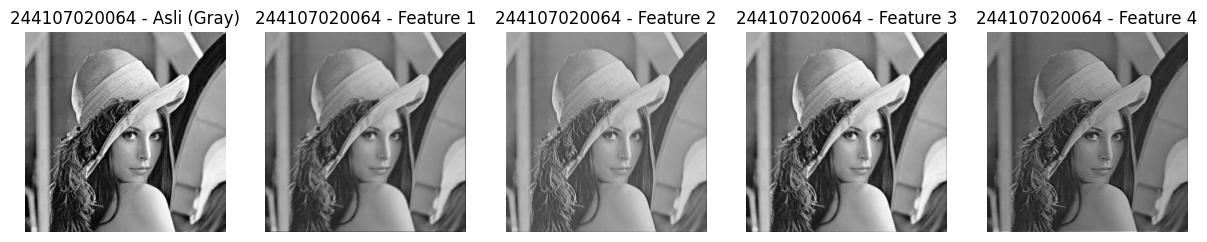

In [ ]:
import torch
import torch.nn as nn

class SimpleCNN(nn.Module):
    def __init__(self):
        super(SimpleCNN, self).__init__()
        self.conv1 = nn.Conv2d(1, 4, kernel_size=3, stride=1, padding=1)

    def forward(self, x):
        return self.conv1(x)

model = SimpleCNN()

# Ubah gambar ke tensor
img_tensor = torch.tensor(img_gray, dtype=torch.float32).unsqueeze(0).unsqueeze(0) / 255.0

# Hasil CNN
with torch.no_grad():
    features = model(img_tensor)

# Visualisasi feature maps
feature_maps = [features[0,i].numpy() for i in range(features.shape[1])]
show_side_by_side([img_gray] + feature_maps, [NIM+" - Asli (Gray)"] + [NIM+f" - Feature {i+1}" for i in range(len(feature_maps))])


## **Percobaan 4**
**efek Beauty dan Vintage yang biasanya digunakan pada Aplikasi
popular saat ini. Filter yang digunakan merupakan kombinasi dari filter tradisional.**

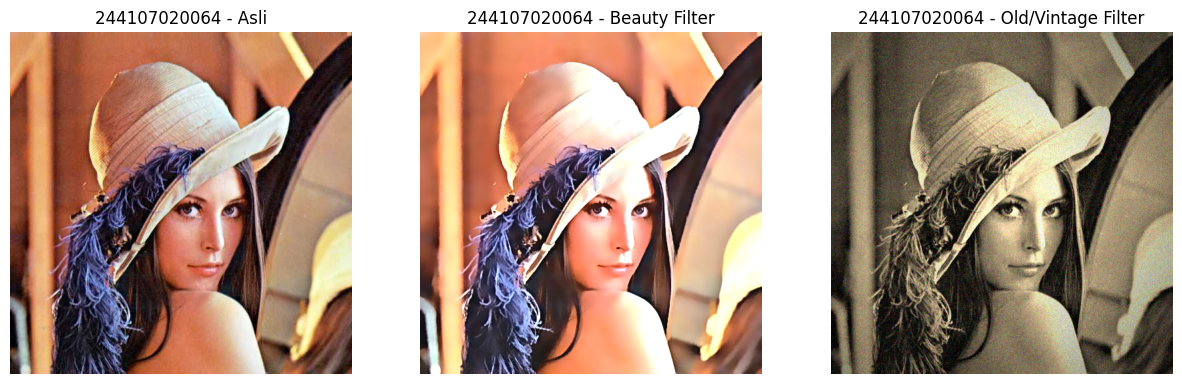

In [ ]:
# ===================
# 1. Beauty Filter
# ===================

# Step 1: Smoothing kulit dengan bilateral filter
smooth = cv.bilateralFilter(img, d=15, sigmaColor=75, sigmaSpace=75)

# Step 2: Unsharp masking (pertajam mata/bibir)
gaussian = cv.GaussianBlur(smooth, (0,0), 3)
sharpened = cv.addWeighted(smooth, 1.5, gaussian, -0.5, 0)

# Step 3: Brightness & contrast
alpha = 1.2  # contrast
beta = 15    # brightness
beauty = cv.convertScaleAbs(sharpened, alpha=alpha, beta=beta)

# ===================
# 2. Old/Vintage Filter
# ===================

# Step 1: Sepia tone
sepia_kernel = np.array([[0.272, 0.534, 0.131],
                         [0.349, 0.686, 0.168],
                         [0.393, 0.769, 0.189]])

sepia = cv.transform(img, sepia_kernel)
sepia = np.clip(sepia, 0, 255).astype(np.uint8)

# Step 2: Vignette
rows, cols = img.shape[:2]
kernel_x = cv.getGaussianKernel(cols, cols*0.6)
kernel_y = cv.getGaussianKernel(rows, rows*0.6)
kernel = kernel_y * kernel_x.T
mask = kernel / kernel.max()
vignette = np.copy(sepia)
for i in range(3):
    vignette[:,:,i] = vignette[:,:,i] * mask

# Step 3: Noise/Grain
noise = np.random.normal(0, 15, vignette.shape).astype(np.int16)
old_img = np.clip(vignette.astype(np.int16) + noise, 0, 255).astype(np.uint8)


# Menampilkan
show_side_by_side(
    [img, beauty, old_img],
    [NIM+" - Asli",
     NIM+" - Beauty Filter",
     NIM+" - Old/Vintage Filter"]
)

## **Percobaan 5**
**filter anime / cartoon menggunakan kombinasi filter
tradisional.**

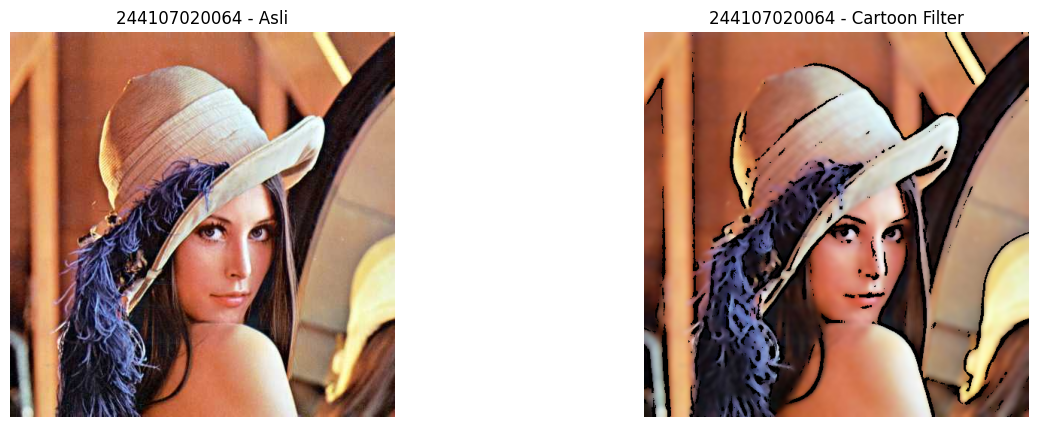

In [ ]:
#Filter Anime / Cartoon
# Step 1: Edge detection (pakai median blur dulu agar gambar menjadi lebih halus)
gray = cv.cvtColor(img, cv.COLOR_BGR2GRAY)
gray_blur = cv.medianBlur(gray, 7)
edges = cv.adaptiveThreshold(gray_blur, 255,
                             cv.ADAPTIVE_THRESH_MEAN_C,
                             cv.THRESH_BINARY, 9, 9)

# Step 2: Bilateral filter untuk smoothing warna
color = cv.bilateralFilter(img, d=9, sigmaColor=200, sigmaSpace=200)

# Step 3: Gabungkan (cartoonize)
cartoon = cv.bitwise_and(color, color, mask=edges)

# Tampilkan
show_side_by_side([img, cartoon], [NIM+" - Asli",
                                   NIM+" - Cartoon Filter"])


## **Percobaan 6**
**FIlter Malam**

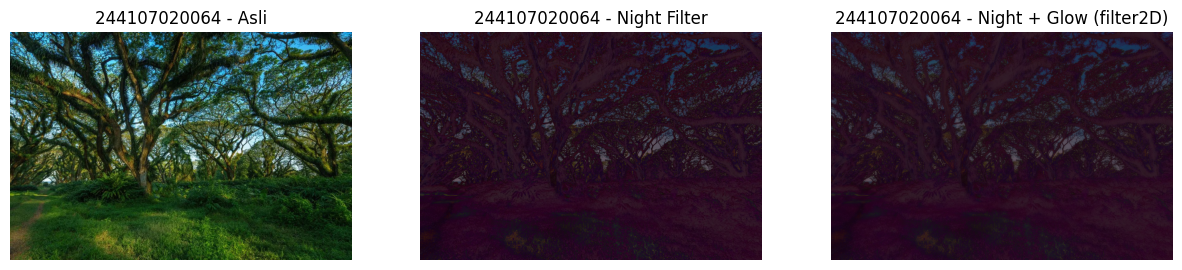

In [ ]:
#Night Filter
img = cv.imread("/content/drive/MyDrive/PCVK/Images/djawatan.jpg")
img_gray = cv.cvtColor(img,cv.COLOR_BGR2GRAY)

# Step 1: Gelapkan (contrast turun, brightness negatif)
night = cv.convertScaleAbs(img, alpha=0.6, beta=-40)

# Step 2: Tambah bias biru
blue_tint = np.full_like(night, (50, 0, 100))
night = cv.addWeighted(night, 0.8, blue_tint, 0.2, 0)

# Step 3: Efek Glow di area terang dengan filter2D (blur kernel)
kernel = np.ones((15,15), np.float32) / 225
glow = cv.filter2D(night, -1, kernel)

# Kombinasikan asli + glow
night_glow = cv.addWeighted(night, 0.7, glow, 0.3, 0)

show_side_by_side(
    [img, night, night_glow],
    [NIM+" - Asli",
     NIM+" - Night Filter",
     NIM+" - Night + Glow (filter2D)"]
)

## **Percobaan 7**
**Filter Pagi dan efek kabut**


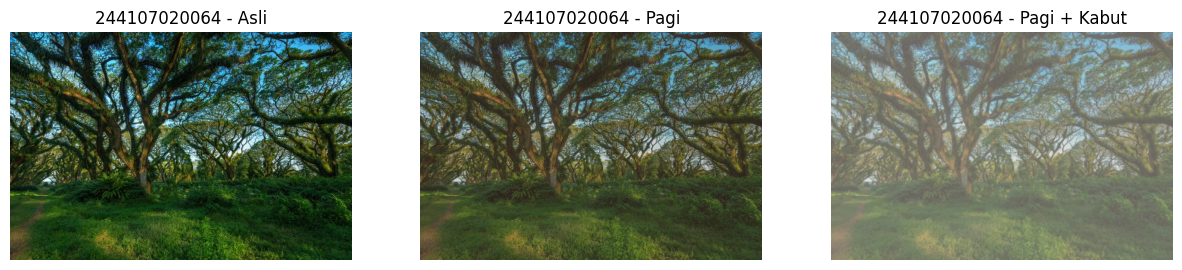

In [ ]:
#Filter Suasana pagi dan Kabut
# =========================
# Step 1: Kurangi kontras & cerahkan
# =========================

alpha = 0.9    # contrast
beta = 20      # brightness
soft = cv.convertScaleAbs(img, alpha=alpha, beta=beta)

# =========================
# Step 2: Tambahkan warm tone (kemerahan / oranye)
# =========================
warm_tint = np.full_like(soft, (40, 70, 120))  # BGR
pagi = cv.addWeighted(soft, 0.8, warm_tint, 0.2, 0)

# =========================
# Step 3: Tambahkan haze (kabut tipis) dengan filter2D
# =========================
# Kernel blur Gaussian-like untuk menciptakan efek kabut
kernel = cv.getGaussianKernel(3, 3)
kernel = kernel @ kernel.T  # jadikan 2D kernel
kabut = cv.filter2D(pagi, -1, kernel)

# tambah layer putih untuk kabut lebih nyata
white_layer = np.full_like(pagi, 255)
kabut = cv.addWeighted(kabut, 0.7, white_layer, 0.3, 0)

show_side_by_side([img, pagi, kabut],
                  [NIM+" - Asli",
                   NIM+" - Pagi",
                   NIM+" - Pagi + Kabut"])

# **Tugas Praktikum**
1. Tugas Analisis: Perbandingan Mean Filter (Blur Biasa) vs. Median Filter pada Noise “Salt and
Pepper”
- Tambahkan noise bintik hitam-putih (Salt and Pepper) ke sebuah citra keabuan (grayscale).
- Terapkan Mean Filter(3 x 3) dan Median Filter (3 x 3).
Pengolahan Citra dan Visi Komputer – Jurusan Teknologi Informasi
- Amati dan analisis secara visual mengapa Median Filter jauh lebih bersih dalam menghapus
noise tersebut dibanding Mean Filter.

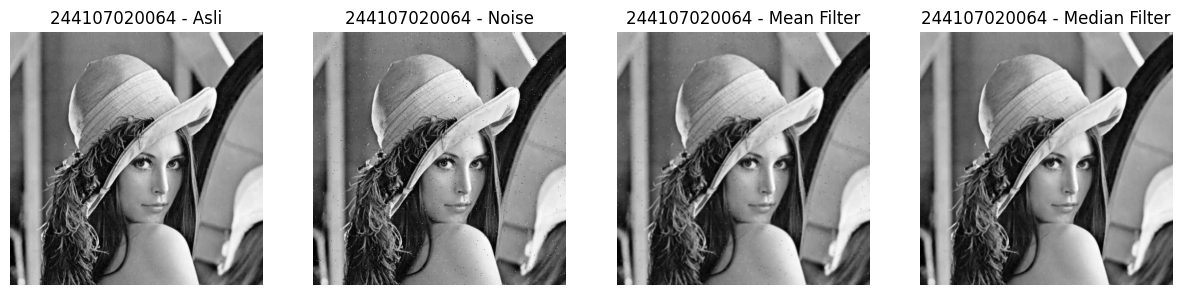

In [ ]:
img = cv.imread("/content/drive/MyDrive/PCVK/Images/lena.jpg")
img_gray = cv.cvtColor(img, cv.COLOR_BGR2GRAY)

#Tambah noise "Salt and Pepper"
noise_img = img_gray.copy()
for i in range(1000):
    x = np.random.randint(0, noise_img.shape[0])
    y = np.random.randint(0, noise_img.shape[1])
    noise_img[x, y] = 255 if np.random.rand() < 0.5 else 0

#Mean Filter 3x3
mean_filter = cv.blur(noise_img, (3, 3))

#Median Filter 3x3
median_filter = cv.medianBlur(noise_img, 3)

#menampilkan
show_side_by_side([img_gray, noise_img, mean_filter, median_filter],
                  [NIM+" - Asli",
                   NIM+" - Noise",
                   NIM+" - Mean Filter",
                   NIM+" - Median Filter"])

**Analisis :**

- Median lebih bersih karena median dapat menghilangkan bintik hitam / noise tanpa merusak gambar asli.
- Mean lebih buram dikarenakan Mean menghitung rata rata, sehingga noise ikut tercampur

2. Tugas Evaluasi: Pemilihan Ukuran Kernel terbaik untuk Menajamkan Citra (Sharpening)
- Buat kernel penajaman (Sharpening Kernel) ukuran 3 x 3 dan 5 x 5.
- Terapkan pada citra yang sedikit buram (blurry).
- Evaluasi hasilnya berdasarkan aspek Kejelasan Tepi vs. Kadar Noise/Noise Distortion yang
dihasilkan. Tentukan kernel mana yang paling optimal untuk digunakan sehari-hari.

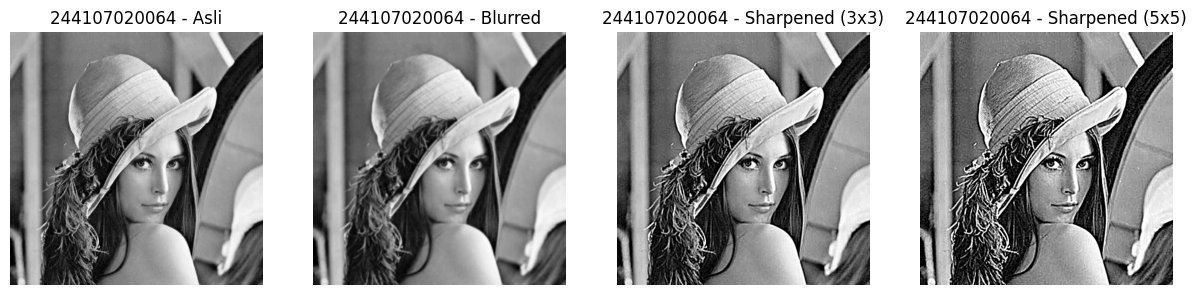

In [ ]:
#Membuat kernel sharepen uk 3x3 dan 5x5
kernel_3x3 = np.array([
    [-1, -1, -1],
    [-1, 9, -1],
    [-1, -1, -1]
])
kernel_5x5 = np.array([
    [0, 0, -1, 0, 0],
    [0, -1, -1, -1, 0],
    [-1, -1, 13, -1, -1],
    [0, -1, -1, -1, 0],
    [0, 0, -1, 0, 0]
])
#Menerapkan blurry
blurry = cv.GaussianBlur(img_gray,(5,5),0)

sharpen_3x3 = cv.filter2D(blurry, -1, kernel_3x3)
sharpen_5x5 = cv.filter2D(blurry, -1, kernel_5x5)

#Menampilkan
show_side_by_side([img_gray, blurry, sharpen_3x3, sharpen_5x5],
                  [NIM+" - Asli",
                   NIM+" - Blurred",
                   NIM+" - Sharpened (3x3)",
                   NIM+" - Sharpened (5x5)"]
)

## **Analisa:**

- Sharpen 3x3 : Membuat tepi gambar menjadi lebih jelas & tajam. Noise relatif sedikit sehingga gambar terlihat natural
- Sharpen 5x5 : Membuat tepi gambar semakin tajam, yang menyebabkan beberapa bagian lebih kontras dan memunculkan efek noise pada rambut dan detail wajah
- Kesimpulan : Berdasarkan hasil pengerjaan dan pengamatan. Sharpen 3x3 relatif lebih optimal digunakan sehari hari karena adanya keseimbangan antara ketajaman dan kadar noise. Sehingga Sharpen 5x5 relatif digunakan jika membutuhkan ketajaman yang lebih kuat

3. Tugas Kreasi: Filter Kartun Sederhana
- Buatlah sebuah fungsi kustom bernama kartun(image) yang menggabungkan:
    * Penghalusan warna menggunakan **Bilateral Filter** agar area warna menjadi rata.
    * Deteksi garis tepi menggunakan **Adaptive Thresholding** atau **Canny Edge**.
    * Penggabungan (kombinasi) keduanya menggunakan operasi logika/perkalian piksel.
- Tampilkan hasil citra asli dengan citra efek kartun bersebelahan.

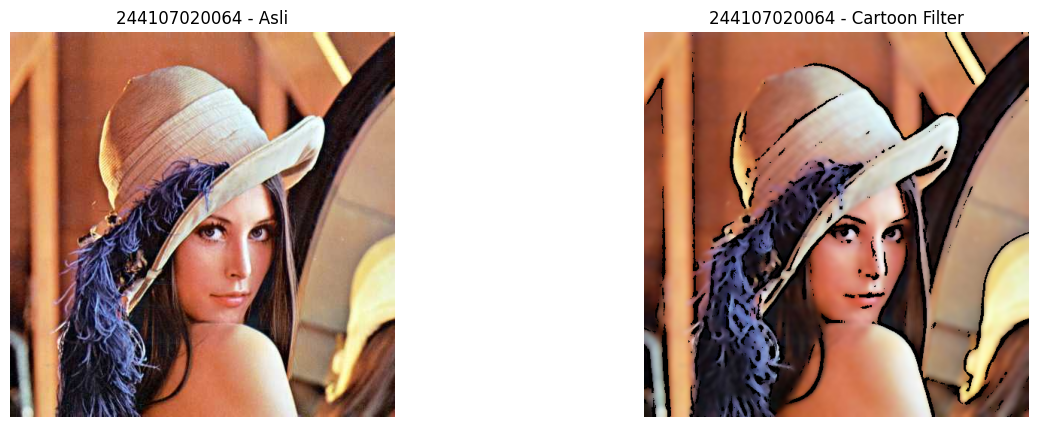

In [ ]:
def kartun(image):
  #Penghalusan Warna
  color = cv.bilateralFilter(image, d=9, sigmaColor=200, sigmaSpace=200)

  #Deteksi Garis
  gray = cv.cvtColor(image, cv.COLOR_BGR2GRAY)
  gray_blur = cv.medianBlur(gray, 7)
  edges = cv.adaptiveThreshold(gray_blur, 255,
                               cv.ADAPTIVE_THRESH_MEAN_C,
                               cv.THRESH_BINARY, 9, 9)

  #Penggabungan
  cartoon = cv.bitwise_and(color, color, mask=edges)
  return cartoon

cartoon_image = kartun(img)

show_side_by_side([img, cartoon_image], [NIM+" - Asli", NIM+" - Cartoon Filter"])

Efek Kartun membuat warna pada citra menjadi lebih rata dan halus karena menggunakan Bilateral Filter, Garis tepi terlihat lebih jelas karena menggunakan Adaptive Thresolding. setelah digabungkan citra asli berubah menjadi tampilan kartun dengan warna yang lebih sederhana dan garis tepi yang tegas